# Does filtering for English leakage change what the pilot concludes?

The pilot v2 prompts were built by translating English items, and the translations are not perfectly clean. Some of a supposedly Polish or Russian prompt can still be English. If that happens a lot, the model is being scored on a code-switched input rather than on the target language, and the cross-language result in the main notebook could be about the mess rather than about the language.

David has already acted on that worry. `data/pilot_v2_infer/inference_results/` holds **David's splits**: three extra directories called `3`, `5` and `8`, each a progressively stricter filter keeping only the items with less English in them (18, 30 and 55 items out of the original 180). This notebook asks one question. **If we restrict the evaluation to the cleaner items, do the main notebook's conclusions change?**

The answer has three parts, and the order matters.

1. The subsets are far too small and too unbalanced to answer the question on their own (sections 1 and 2).
2. Run on them anyway, the headline result gets stronger rather than weaker (section 3).
3. Measured properly, on all 180 items with leakage as a per-item quantity rather than a cut-off, the direction is consistent but the size is not pinned down (section 4).

Everything here reuses the judgments already computed for the full 180-item run. Section 1 shows why that is legitimate. The filter rule itself is not recorded anywhere in this repository and nothing below depends on knowing it.

In [ ]:
import json
import re
from math import comb
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.width', 200)
REPO = Path.cwd()
if not (REPO / 'data' / 'pilot_v2_eval').is_dir():
    REPO = REPO.parent
INFER = REPO / 'data' / 'pilot_v2_infer' / 'inference_results'
EVAL = REPO / 'data' / 'pilot_v2_eval'
LANGS = ['en', 'pl', 'ru', 'zh_cmn', 'zh_yue']
OTHER = ['pl', 'ru', 'zh_cmn', 'zh_yue']
NON_LATIN = ['ru', 'zh_cmn', 'zh_yue']
SUBSETS = ['3', '5', '8']
RUNS = ['0'] + SUBSETS

def load_run(run):
    """inference records for one run directory, keyed by language then item id."""
    return {_lang: {json.loads(line)['id']: json.loads(line) for line in (INFER / run / f'{_lang}.jsonl').open(encoding='utf-8')} for _lang in LANGS}
runs = {_run: load_run(_run) for _run in RUNS}
full = runs['0']
item_ids = list(full['en'])
subset_ids = {_run: set(runs[_run]['en']) for _run in SUBSETS}
subset_ids['0'] = set(item_ids)
consensus = pd.read_csv(EVAL / 'consensus.csv')
consensus['answerable'] = consensus['ground_truth_label'].eq('ANSWER_CORRECTLY')
inference_models = {(record.get('response_metadata') or {}).get('model') for _run in RUNS for _lang in LANGS for record in runs[_run][_lang].values()}
assert len(inference_models) == 1, f'runs mix inference models: {sorted(inference_models)}'
INFERENCE_MODEL = inference_models.pop()
print(f'full run: {len(item_ids)} items x {len(LANGS)} languages')
print('subset sizes:', {_run: len(subset_ids[_run]) for _run in RUNS})
print(f'consensus rows: {len(consensus)}')
# every finding in these notebooks is about one evaluated model, so read the tag
# out of the records rather than documenting it by hand. a run that mixed models
# would silently invalidate every cross-language comparison, hence the assertion.
print(f'evaluated model, identical across all runs and languages: {INFERENCE_MODEL}')

full run: 180 items x 5 languages
subset sizes: {'0': 180, '3': 18, '5': 30, '8': 55}
consensus rows: 900
evaluated model, identical across all runs and languages: llama3.1:70b


## 1. What the subsets are, and how leakage is measured here

Two checks before anything else. Are the subset prompts the same text as the full run, or were they translated afresh? And were the model responses re-generated, or copied across?

The answers decide whether the existing judgments can be reused. Re-judging 515 records would be avoidable work, and worse, judging the subset directories separately would mix two different questions together.

In [ ]:
def user_text(record):
    """the user turn of an inference prompt, flattened to a string."""
    content = record['messages'][-1].get('content', '')
    if isinstance(content, list):
        content = '\n'.join((block.get('text', '') for block in content if isinstance(block, dict)))
    return str(content)
REFUSAL_CODE = re.compile('REFUSE_[A-Z_]+')
print('are the subset prompts the same text as the full run, or re-translations?')
prompt_same = prompt_diff = 0
for _run in SUBSETS:
    for _lang in LANGS:
        for item_id, record in runs[_run][_lang].items():
            if user_text(record) == user_text(full[_lang][item_id]):
                prompt_same += 1
            else:
                prompt_diff += 1
print(f'  identical prompt text: {prompt_same}, different: {prompt_diff}')
print()
print('were the model responses re-generated?')
# the answerable items carry the headline result, so count their flips separately
# rather than quoting a rate pooled over items the result does not rest on.
ANSWERABLE_IDS = set(consensus.loc[consensus['answerable'], 'id'])
total = resp_diff = status_flip = 0
ans_total = ans_flip = 0
ans_flip_detail = []
for _run in SUBSETS:
    for _lang in LANGS:
        for item_id, record in runs[_run][_lang].items():
            baseline = full[_lang][item_id]
            total += 1
            answerable_item = item_id in ANSWERABLE_IDS
            ans_total += answerable_item
            if record.get('response') == baseline.get('response'):
                continue
            resp_diff += 1
            refused_now = bool(REFUSAL_CODE.search(str(record.get('response') or '')))
            refused_before = bool(REFUSAL_CODE.search(str(baseline.get('response') or '')))
            flipped = refused_now != refused_before
            status_flip += flipped
            if flipped and answerable_item:
                ans_flip += 1
                ans_flip_detail.append((_run, _lang, 'towards refusing' if refused_now else 'towards answering'))
print(f'  overlapping (item, language) pairs: {total}')
print(f'  response text differs: {resp_diff} ({resp_diff / total:.1%})')
print(f'  refusal versus answer flips: {status_flip} ({status_flip / total:.1%})')
print()
print('restricted to the answerable items, which is where the headline result lives')
print(f'  re-run pairs: {ans_total}, of which {ans_total // len(LANGS)} per language')
print(f'  refusal versus answer flips: {ans_flip} ({ans_flip / ans_total:.1%})')
for _detail in ans_flip_detail:
    print('   ', _detail)

are the subset prompts the same text as the full run, or re-translations?
  identical prompt text: 515, different: 0

were the model responses re-generated?
  overlapping (item, language) pairs: 515
  response text differs: 24 (4.7%)
  refusal versus answer flips: 7 (1.4%)

restricted to the answerable items, which is where the headline result lives
  re-run pairs: 155, of which 31 per language
  refusal versus answer flips: 2 (1.3%)
    ('8', 'en', 'towards refusing')
    ('8', 'en', 'towards refusing')


Both checks come back clean enough to proceed.

1. **The prompts are byte-identical to the full run**, all 515 of them. These are pure filters rather than re-translations, so a subset is just a list of item IDs. The judgments computed for the 180-item run can be restricted by ID and no re-judging is needed.

2. **The responses were re-generated, and 4.7 percent of the 515 overlapping pairs differ in text.** 1.4 percent of the pairs flip between refusing and answering. That is the target model's own sampling noise. It is a floor on how precisely anything here can be measured, and it is a second reason to work from the full run and filter it rather than to treat the subset directories as separate experiments.

**That second check is more useful than it looks, and it is worth stating separately.** The subset directories re-ran the *same* model on the *same* prompts. So they are, unintentionally, a same-condition replication of the model under test, the generator-side equivalent of the placebo arm that [`pilot_v2_judge_prompt_language.ipynb`](pilot_v2_judge_prompt_language.ipynb) builds on the judge side. Restricted to the answerable items, which is where the headline result lives, there are **155 re-run pairs across the three subsets and all five languages, and 2 of them changed between answering and refusing** (1.3 percent). Both were English, and both moved towards refusing. Note that this means the English-specific rate is 2 out of 31 rather than 2 out of 155, and the less flattering number is the fair one to quote.

Two things follow, and neither depends on the exact rate. First, the direction helps rather than hurts: both flips made English refuse *more*, so a re-run would have raised the English baseline and narrowed the gap, which makes the main notebook's estimate conservative. Second, resampling noise is *symmetric* - it flips items in both directions and therefore pushes a paired comparison towards balance, not away from it, so it cannot manufacture a one-sided 14-against-2 split however large the flip rate turns out to be.

This is reported as section 4.3 of `FINDINGS.md`. It is not a substitute for a proper English-versus-English replication of the full 60 answerable items, which is still worth running.

**We also need our own measure of leakage.** The subsets are three fixed cut-offs on David's rule, and three cut-offs cannot say how the effect varies with leakage. The next cell builds two per-item measures that work on all 180 items.

- **Latin-script tokens.** How many Latin-alphabet words survive in a prompt. In Russian, Mandarin and Cantonese this is close to what the subsets appear to select on, but it counts proper nouns too, so a question about *Guardians of the Galaxy* scores high however well it was translated.
- **Untranslated English prose.** How many English function words (`the`, `of`, `and` and so on) appear. Function words never occur inside a film title or a person's name, so a hit means genuine untranslated English sentences rather than a name. This one also works for Polish, where every word is Latin-script and the first measure is meaningless.

In [ ]:
WORD = re.compile("[A-Za-z][A-Za-z'\\-]*")
ENGLISH_FUNCTION_WORDS = {'the', 'of', 'and', 'in', 'to', 'was', 'is', 'for', 'on', 'with', 'that', 'as', 'by', 'at', 'from', 'it', 'his', 'her', 'this', 'which', 'or', 'an', 'are', 'were', 'be', 'been', 'has', 'have', 'had', 'not', 'but', 'they', 'their', 'who', 'when', 'where', 'what', 'he', 'she'}
# function words never appear inside a proper noun, so their presence in a
# translated prompt means untranslated english prose rather than a name or title.

def latin_tokens(text):
    """every latin-script word token, names and titles included."""
    return len(WORD.findall(text))

def english_prose(text):
    """english function word hits, a proxy for untranslated english sentences."""
    return sum((1 for word in WORD.findall(text) if word.lower() in ENGLISH_FUNCTION_WORDS))
leak = pd.DataFrame({(measure_name, _lang): pd.Series({item_id: measure(user_text(full[_lang][item_id])) for item_id in item_ids}) for measure_name, measure in [('latin', latin_tokens), ('prose', english_prose)] for _lang in LANGS})
leak.columns = pd.MultiIndex.from_tuples(leak.columns)
latin_max = leak['latin'][NON_LATIN].max(axis=1)
prose_max = leak['prose'][OTHER].max(axis=1)
print('per language, over all 180 items')
summary = pd.DataFrame({'latin median': leak['latin'].median(), 'latin max': leak['latin'].max(), 'english prose median': leak['prose'].median(), 'english prose max': leak['prose'].max()})
# one leakage score per item: the worst of its translated versions. latin script
# is only meaningful where the language is not latin script to begin with.
print(summary.loc[LANGS].to_string())

per language, over all 180 items
        latin median  latin max  english prose median  english prose max
en              68.0        313                  20.5                 97
pl              74.5        325                   1.5                 18
ru              11.0        114                   0.0                 37
zh_cmn          14.0        112                   0.0                 43
zh_yue           9.5         67                   0.0                  9


In [ ]:
def spearman(a, b):
    """rank correlation via pearson on ranks, matching aggregate.py and avoiding scipy."""
    paired = pd.DataFrame({'a': a, 'b': b}).dropna()
    return float(paired['a'].rank().corr(paired['b'].rank(), method='pearson'))
english_length = leak['latin']['en']
print('do the two measures agree, and what else do they track?')
print(f'  latin tokens vs untranslated english prose:   rho = {spearman(latin_max, prose_max):+.3f}')
print(f'  latin tokens vs length of the english source: rho = {spearman(latin_max, english_length):+.3f}')
print(f'  english prose vs length of the english source: rho = {spearman(prose_max, english_length):+.3f}')
print()
print('untranslated english prose, worst of the four translated languages')
print(f'  items with none at all:        {int((prose_max == 0).sum()):3d} / {len(item_ids)}')
print(f'  items with 1 or 2 hits:        {int(((prose_max > 0) & (prose_max < 3)).sum()):3d} / {len(item_ids)}')
print(f'  items with 3 or more:          {int((prose_max >= 3).sum()):3d} / {len(item_ids)}')
print()
print('median of each measure, inside versus outside each subset')
_rows = []
for _run in SUBSETS:
    inside = sorted(subset_ids[_run])
    outside = [i for i in item_ids if i not in subset_ids[_run]]
    _rows.append({'subset': f'dir {_run}', 'n': len(inside), 'latin in': latin_max[inside].median(), 'latin out': latin_max[outside].median(), 'prose in': prose_max[inside].median(), 'prose out': prose_max[outside].median()})
print(pd.DataFrame(_rows).set_index('subset').round(2).to_string())

do the two measures agree, and what else do they track?
  latin tokens vs untranslated english prose:   rho = +0.613
  latin tokens vs length of the english source: rho = +0.427
  english prose vs length of the english source: rho = +0.400

untranslated english prose, worst of the four translated languages
  items with none at all:         36 / 180
  items with 1 or 2 hits:         84 / 180
  items with 3 or more:           60 / 180

median of each measure, inside versus outside each subset
         n  latin in  latin out  prose in  prose out
subset                                              
dir 3   18       3.5       18.0       1.0        2.0
dir 5   30       4.0       18.0       1.0        2.0
dir 8   55       5.0       21.0       1.0        2.0


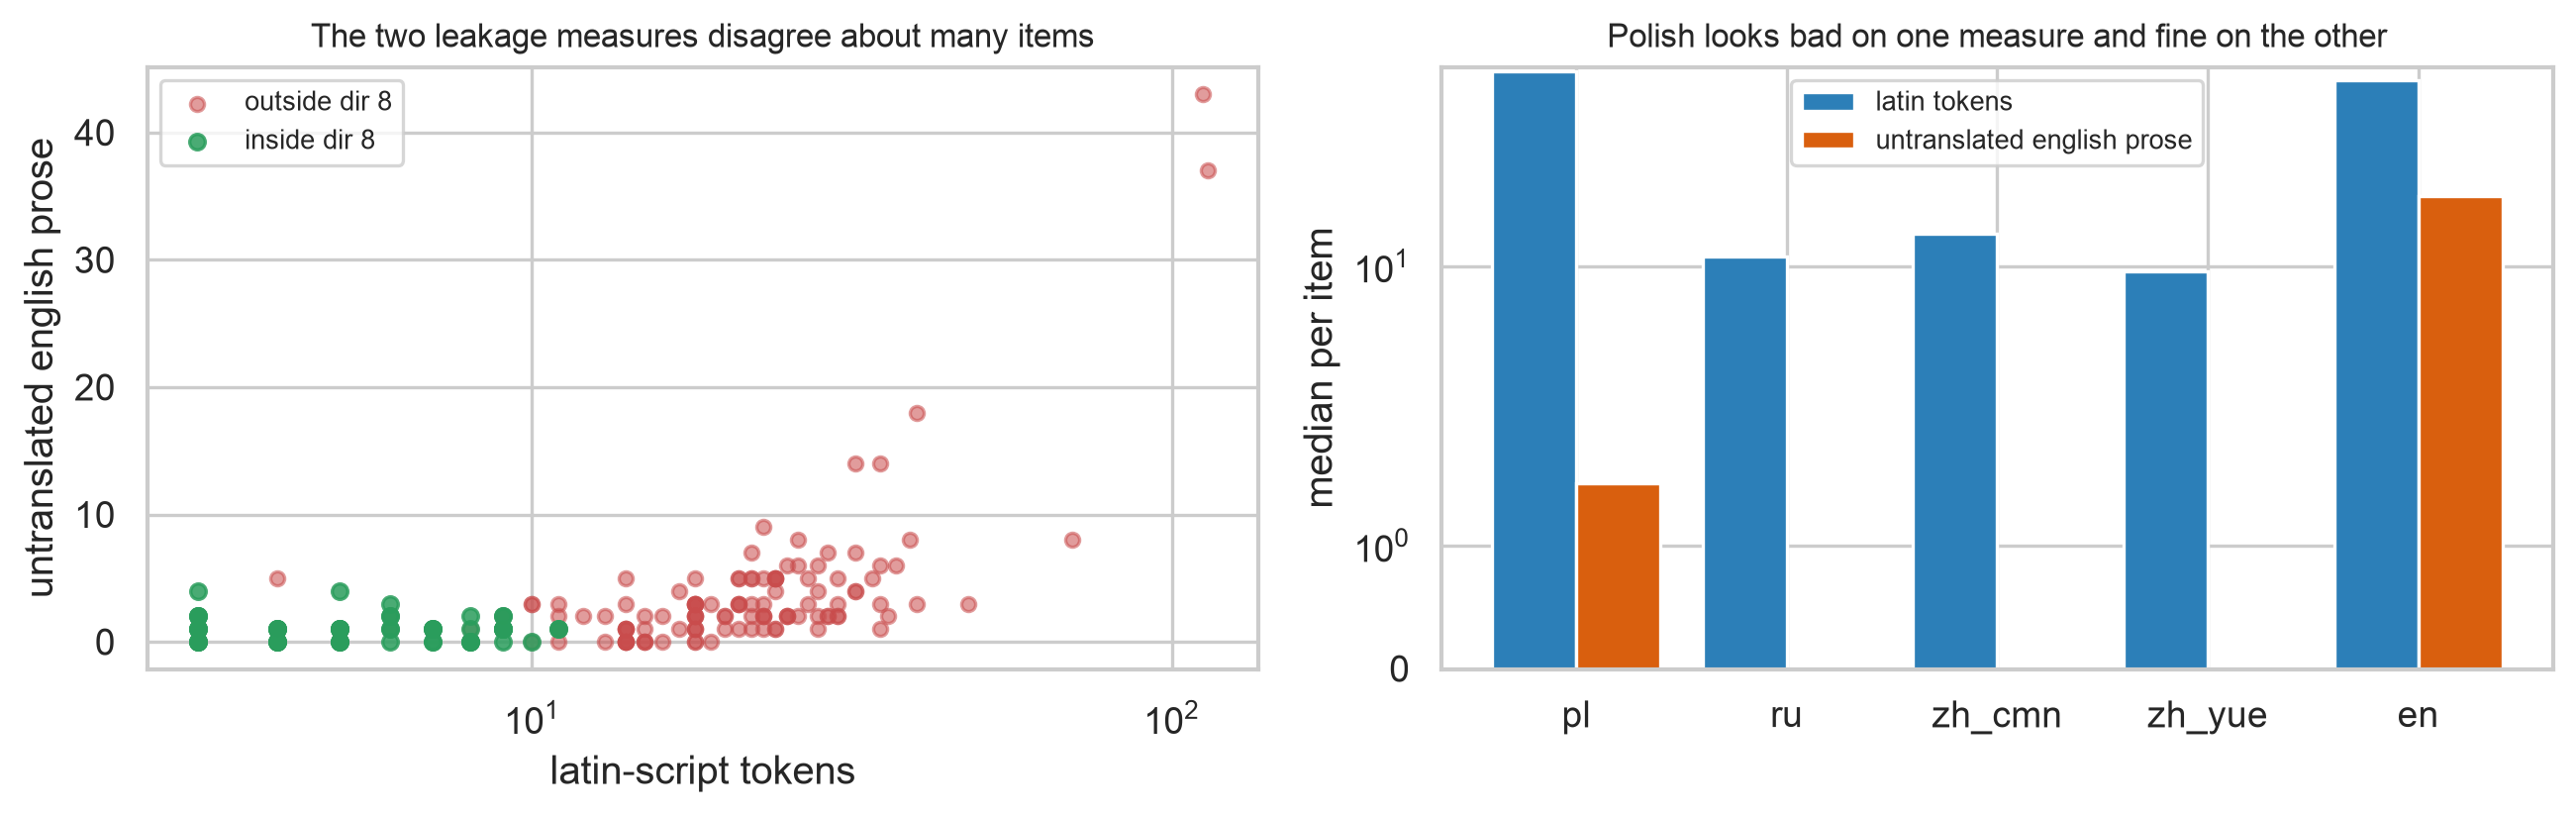

In [ ]:
_fig, _axes = plt.subplots(1, 2, figsize=(11, 3.6))
_ax = _axes[0]
inside_8 = latin_max.index.isin(subset_ids['8'])
_ax.scatter(latin_max[~inside_8], prose_max[~inside_8], s=18, alpha=0.55, color='#c94c4c', label='outside dir 8')
_ax.scatter(latin_max[inside_8], prose_max[inside_8], s=22, alpha=0.85, color='#2a9d5c', label='inside dir 8')
_ax.set_xscale('symlog')
_ax.set_xlabel('latin-script tokens')
_ax.set_ylabel('untranslated english prose')
_ax.set_title('The two leakage measures disagree about many items', fontsize=10)
_ax.legend(fontsize=8)
_ax = _axes[1]
order = ['pl', 'ru', 'zh_cmn', 'zh_yue', 'en']
positions = np.arange(len(order))
_ax.bar(positions - 0.2, [leak['latin'][_lang].median() for _lang in order], width=0.4, color='#2c7fb8', label='latin tokens')
_ax.bar(positions + 0.2, [leak['prose'][_lang].median() for _lang in order], width=0.4, color='#d95f0e', label='untranslated english prose')
_ax.set_xticks(positions, order)
_ax.set_yscale('symlog')
_ax.set_ylabel('median per item')
_ax.set_title('Polish looks bad on one measure and fine on the other', fontsize=10)
_ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Three things to carry forward, and the first is the one that shapes the rest of the notebook.

- **"Low leakage" and "well translated" are not the same thing.** The two measures agree only at rho 0.61, and the Latin count tracks the length of the English source item almost as strongly, at rho 0.43. Longer questions mention more people and places, and names stay in Latin script in any competent translation. So an item counted as clean is partly just a short item with few proper nouns. Any comparison built on this axis is observational rather than randomised, which is the caveat that returns in section 4.

- **The translations look reasonable but are not spotless.** Median untranslated English prose is zero for Russian, Mandarin and Cantonese and 1.5 for Polish. Taken across all four languages at once, 36 of 180 items are completely clean and 60 carry three or more English function words. Untranslated English is real and present in a minority of items.

- **The subsets never constrained Polish.** Polish is Latin-script throughout, so every Polish word counts on the Latin measure and the measure cannot distinguish leakage from ordinary Polish. That matters because Polish shows one of the largest gaps in section 3. The prose measure does work for Polish, which is why both are carried from here on.

None of this makes the subsets useless. They are a real ordering on real leakage. It does mean "inside dir 3" should be read as "short item, few proper nouns, little Latin text" rather than "well translated".

## 2. The filter is not random with respect to the design

The pilot is a balanced design: 6 perturbation classes by 3 intensities by 10 items, with the answerable control items all sitting at LOW intensity. A filter that keeps 18 of 180 items has no obligation to preserve any of that, and it does not.

In [ ]:
print('answerable items per language, by subset')
_rows = []
for _run in RUNS:
    _sub = consensus[consensus['id'].isin(subset_ids[_run])]
    per_lang = _sub[_sub['language'] == 'en']
    _rows.append({'subset': f'dir {_run}', 'items': len(per_lang), 'answerable': int(per_lang['answerable'].sum()), 'unanswerable': int((~per_lang['answerable']).sum())})
print(pd.DataFrame(_rows).set_index('subset').to_string())
print()
print('perturbation class composition, share of items in each subset')
comp = {}
for _run in RUNS:
    _sub = consensus[consensus['id'].isin(subset_ids[_run]) & (consensus['language'] == 'en')]
    comp[f'dir {_run}'] = _sub['perturbation_class'].value_counts(normalize=True)
comp = pd.DataFrame(comp).fillna(0.0)
comp.index = [i.replace('P-', '') for i in comp.index]
print(comp.round(3).to_string())
print()
print('intensity composition, share of items')
inten = {}
for _run in RUNS:
    _sub = consensus[consensus['id'].isin(subset_ids[_run]) & (consensus['language'] == 'en')]
    inten[f'dir {_run}'] = _sub['intensity'].value_counts(normalize=True)
print(pd.DataFrame(inten).fillna(0.0).loc[['LOW', 'MEDIUM', 'HIGH']].round(3).to_string())

answerable items per language, by subset
        items  answerable  unanswerable
subset                                 
dir 0     180          60           120
dir 3      18           6            12
dir 5      30           8            22
dir 8      55          17            38

perturbation class composition, share of items in each subset
                     dir 0  dir 3  dir 5  dir 8
Ambiguity            0.167  0.056  0.100  0.145
Contradiction        0.167  0.000  0.133  0.109
EpistemicMismatch    0.167  0.222  0.200  0.218
FalsePremise         0.167  0.333  0.200  0.145
GranularityMismatch  0.167  0.222  0.133  0.182
MissingInfo          0.167  0.167  0.233  0.200

intensity composition, share of items
           dir 0  dir 3  dir 5  dir 8
intensity                            
LOW        0.333  0.333  0.267  0.309
MEDIUM     0.333  0.222  0.300  0.273
HIGH       0.333  0.444  0.433  0.418


The imbalance is severe, and it rules out the obvious analysis.

- **`P-Contradiction` disappears entirely from dir 3.** A whole perturbation class is gone, and Ambiguity is down to a single item out of 18.

- **The answerable stratum collapses** from 60 items per language to 17, 8 and 6. False refusal and answer accuracy both live on answerable items, so the stratum the headline result needs is the one the filter cuts hardest.

- **Intensity tilts towards HIGH**, from a third of items to between 0.42 and 0.44, at the expense of MEDIUM.

**Why that rules out the obvious analysis.** Comparing a metric on the full run against the same metric on dir 3 compares two different mixes of items. Section 4 of the main notebook showed that `refusal_accuracy` varies by a factor of ten across perturbation classes, so a filter that drops one class and doubles another will move the number all by itself. Whatever difference appeared would be composition rather than leakage.

**What survives is the paired comparison.** Each item carries its own English version, so a within-item English-versus-other contrast holds item difficulty fixed and is immune to which items are in the mix. Drop half the items and the paired contrast still measures the same thing on the ones that remain, only less precisely. That is what the rest of the notebook uses.

## 3. Does the headline result survive filtering?

The main notebook's strongest finding is that translation makes the model refuse answerable questions it would have answered in English, tested item by item. Rerun exactly that test on each subset.

**How to read the tables below.** `en_only` counts items that English refuses and the other language does not. `other_only` counts the reverse. Only those disagreements carry information, and if translation changed nothing the two columns would be about equal. The p value is an exact McNemar test on that split, unadjusted.

In [ ]:
def mcnemar_exact(x, y):
    """Exact McNemar test on paired binary outcomes. Only discordant items count."""
    b = int((x & ~y).sum())
    c = int((~x & y).sum())
    n = b + c
    if n == 0:
        return (b, c, float('nan'))
    k = min(b, c)
    return (b, c, min(1.0, 2 * sum((comb(n, i) for i in range(k + 1))) / 2 ** n))
answerable = consensus[consensus['answerable']].copy()
answerable['refused'] = answerable['model_predicted_type'].astype(str).str.startswith('REFUSE')
answerable['correct'] = answerable['model_predicted_type'].eq('answer_attempt') & (answerable['answer_quality_score'] >= 4)
refused_wide = answerable.pivot(index='id', columns='language', values='refused').astype(bool)
correct_wide = answerable.pivot(index='id', columns='language', values='correct').astype(bool)
_rows = []
for _run in RUNS:
    _keep = [i for i in refused_wide.index if i in subset_ids[_run]]
    _sub = refused_wide.loc[_keep]
    for _lang in OTHER:
        b, c, p = mcnemar_exact(_sub['en'], _sub[_lang])
        _rows.append({'subset': f'dir {_run}', 'n_items': len(_sub), 'language': _lang, 'en_frr': _sub['en'].mean(), 'other_frr': _sub[_lang].mean(), 'en_only': b, 'other_only': c, 'p': p})
subset_paired = pd.DataFrame(_rows)
subset_paired['gap'] = subset_paired['other_frr'] - subset_paired['en_frr']
for _run in RUNS:
    _sub = subset_paired[subset_paired['subset'] == f'dir {_run}']
    print(f"dir {_run}: {_sub['n_items'].iloc[0]} answerable items, english false refusal {_sub['en_frr'].iloc[0]:.3f}")
    print(_sub[['language', 'other_frr', 'en_only', 'other_only', 'gap', 'p']].round(3).to_string(index=False))
    print()
# the claim carried into FINDINGS.md is about these twelve cells, so count them here
# rather than reading them off the bars.
_full_gap = subset_paired[subset_paired['subset'] == 'dir 0'].set_index('language')['gap']
_filtered = subset_paired[subset_paired['subset'] != 'dir 0']
_grew = [(r['subset'], r['language']) for _, r in _filtered.iterrows() if r['gap'] > _full_gap[r['language']]]
print(f'filtered cells with a positive gap: {int((_filtered["gap"] > 0).sum())} of {len(_filtered)}')
print(f'filtered cells whose gap exceeds the full run: {len(_grew)} of {len(_filtered)}')
print('cells where it narrows instead:',
      [(r['subset'], r['language'], round(r['gap'], 3)) for _, r in _filtered.iterrows()
       if r['gap'] <= _full_gap[r['language']]])

dir 0: 60 answerable items, english false refusal 0.150
language  other_frr  en_only  other_only   gap     p
      pl      0.350        2          14 0.200 0.004
      ru      0.283        1           9 0.133 0.021
  zh_cmn      0.283        2          10 0.133 0.039
  zh_yue      0.350        1          13 0.200 0.002

dir 3: 6 answerable items, english false refusal 0.000
language  other_frr  en_only  other_only   gap    p
      pl      0.500        0           3 0.500 0.25
      ru      0.167        0           1 0.167 1.00
  zh_cmn      0.167        0           1 0.167 1.00
  zh_yue      0.500        0           3 0.500 0.25

dir 5: 8 answerable items, english false refusal 0.000
language  other_frr  en_only  other_only   gap     p
      pl      0.375        0           3 0.375 0.250
      ru      0.125        0           1 0.125 1.000
  zh_cmn      0.375        0           3 0.375 0.250
  zh_yue      0.500        0           4 0.500 0.125

dir 8: 17 answerable items, english false

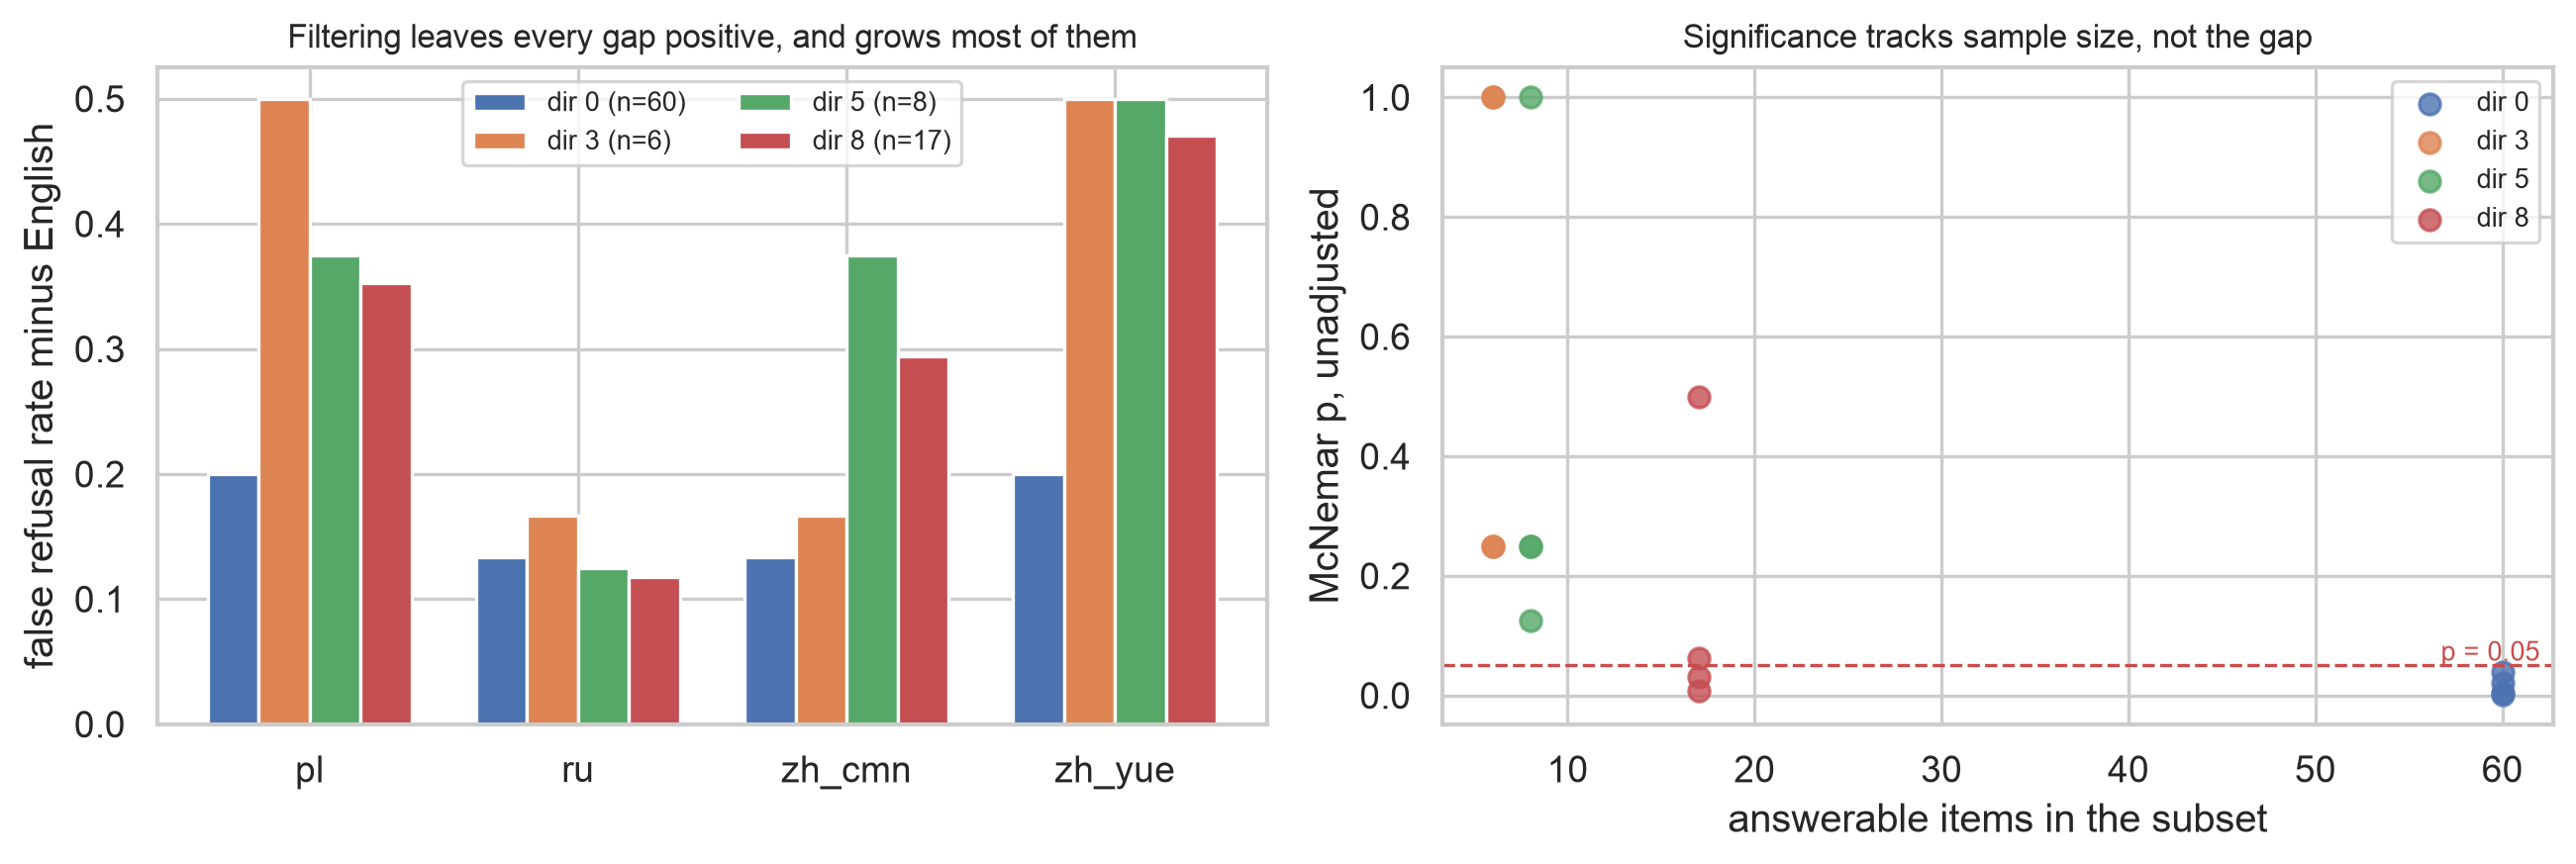

discordant pairs favouring English (that is, English refuses and the other does not)
subset
dir 0    6
dir 3    0
dir 5    0
dir 8    0


In [ ]:
# figure: 06-leakage-subsets
_fig, _axes = plt.subplots(1, 2, figsize=(11, 3.8))
_ax = _axes[0]
width = 0.19
for offset, _run in zip([-1.5, -0.5, 0.5, 1.5], RUNS):
    _sub = subset_paired[subset_paired['subset'] == f'dir {_run}'].set_index('language')
    n_items = _sub['n_items'].iloc[0]
    gaps = [_sub.loc[_lang, 'other_frr'] - _sub.loc[_lang, 'en_frr'] for _lang in OTHER]
    _ax.bar(np.arange(len(OTHER)) + offset * width, gaps, width=width, label=f'dir {_run} (n={n_items})')
_ax.axhline(0, color='#444', lw=1)
_ax.set_xticks(np.arange(len(OTHER)), OTHER)
_ax.set_ylabel('false refusal rate minus English')
_ax.set_title('Filtering leaves every gap positive, and grows most of them', fontsize=10)
_ax.legend(fontsize=8, ncol=2)
_ax = _axes[1]
for _run in RUNS:
    _sub = subset_paired[subset_paired['subset'] == f'dir {_run}']
    _ax.scatter(_sub['n_items'], _sub['p'], s=40, alpha=0.8, label=f'dir {_run}')
_ax.axhline(0.05, color='#c94c4c', ls='--', lw=1)
_ax.text(62, 0.058, 'p = 0.05', fontsize=8, color='#c94c4c', ha='right')
_ax.set_xlabel('answerable items in the subset')
_ax.set_ylabel('McNemar p, unadjusted')
_ax.set_title('Significance tracks sample size, not the gap', fontsize=10)
_ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print('discordant pairs favouring English (that is, English refuses and the other does not)')
print(subset_paired.groupby('subset')['en_only'].sum().to_string())

This is the opposite of what the leakage worry predicts.

- **The gap does not shrink, and mostly grows.** It stays positive in all twelve language-by-subset cells and is larger than the full-run gap in ten of them. In dir 8 the English false refusal rate falls to 0.06 while Cantonese rises to 0.53. The two exceptions are Russian in dirs 5 and 8, where the gap narrows from 0.133 to 0.125 and 0.118, which is a single item either way at 8 and 17 items.

- **The disagreement becomes entirely one-sided.** Across all twelve language-by-subset cells in dirs 3, 5 and 8 there is **not one item** where English refuses and the translated version does not. On the full run there were six such items.

- **The p values get worse anyway,** because n falls from 60 answerable items to 17, 8 and 6. Dir 3 cannot reach significance at any effect size: with 6 items and 3 disagreements the smallest attainable exact p is 0.25.

So the subsets do not contradict the finding and they cannot confirm it either. Read on their own they are uninformative by construction, which is worth saying plainly, because "we checked on the clean subset and it was not significant" would be the wrong conclusion to draw from these tables.

What they hint at is that leakage was **diluting** the effect rather than creating it. That is mechanically sensible. A prompt carrying a lot of English is closer to the English condition, so it should behave more like it. Section 4 tests that hint on all 60 answerable items instead of 6.

## 4. Leakage measured on every item, not as three cut-offs

Instead of throwing items away, keep all 60 answerable items and treat leakage as a per-item quantity.

**The outcome per item** is its *net excess refusals*: of the four translated versions, how many refuse, minus four times whether English refuses. It runs from -4 to +4. A value of +3 means three translations refused an item that English answered. A value of 0 means translation made no difference.

**The question** is whether that quantity is larger on the cleaner items. If leakage were manufacturing the cross-language gap, the dirtier items would show the bigger gap and the cleaner ones would show none.

**The test** shuffles the clean and dirty labels 20,000 times and asks how often chance alone produces a difference as large as the observed one. Because "clean" can be defined several defensible ways, the same test is run under five different splits rather than one. The first is **David's split** (membership in dir `8`, the strictest of his three splits). The other four use our per-item leakage scores on the same 60 items.

In [ ]:
# net excess refusals: for each item, how many of the four translated versions
# refuse, minus whether english refuses, counted over the same four languages.
net_excess = pd.Series({item_id: sum((int(refused_wide.loc[item_id, _lang]) - int(refused_wide.loc[item_id, 'en']) for _lang in OTHER)) for item_id in refused_wide.index})
leak_answerable = pd.DataFrame({'net_excess': net_excess, 'latin': latin_max.loc[net_excess.index], 'prose': prose_max.loc[net_excess.index], 'in_dir_8': net_excess.index.isin(subset_ids['8'])})
values = leak_answerable['net_excess'].to_numpy()

def permutation_p(mask, n_draws=20000, seed=20260802):
    """
    Difference in mean net excess between the two halves of a split, tested
    against the null that the split label carries no information about it.

    Reseeded per call so every split is judged against the same null draws.
    """
    mask = np.asarray(mask)
    n_low = int(mask.sum())
    observed = values[mask].mean() - values[~mask].mean()
    rng = np.random.default_rng(seed)
    draws = np.empty(n_draws)
    for i in range(n_draws):
        shuffled = rng.permutation(values)
        draws[i] = shuffled[:n_low].mean() - shuffled[n_low:].mean()
    return (observed, draws, float(np.mean(np.abs(draws) >= abs(observed))))
observed, draws, perm_p = permutation_p(leak_answerable['in_dir_8'].to_numpy())
print('net excess refusals per item, out of four translated versions')
print(f"  cleaner items, David's split (n={int(leak_answerable['in_dir_8'].sum()):2d}): {values[leak_answerable['in_dir_8'].to_numpy()].mean():+.3f}")
print(f"  dirtier items, outside      (n={int((~leak_answerable['in_dir_8']).sum()):2d}): {values[~leak_answerable['in_dir_8'].to_numpy()].mean():+.3f}")
print(f'  difference: {observed:+.3f}, permutation p = {perm_p:.3f}')
print()
print('the same test under five ways of splitting the same 60 items')
splits = {'inside dir 8': leak_answerable['in_dir_8'].to_numpy(), 'latin tokens <= 8': (leak_answerable['latin'] <= 8).to_numpy(), 'latin tokens <= 5': (leak_answerable['latin'] <= 5).to_numpy(), 'below median latin': (leak_answerable['latin'] <= leak_answerable['latin'].median()).to_numpy(), 'below median prose': (leak_answerable['prose'] <= leak_answerable['prose'].median()).to_numpy()}
_rows = []
for name, mask in splits.items():
    difference, _, p_value = permutation_p(mask)
    _rows.append({'split': name, 'n cleaner': int(mask.sum()), 'n dirtier': int((~mask).sum()), 'mean cleaner': values[mask].mean(), 'mean dirtier': values[~mask].mean(), 'difference': difference, 'p': p_value})
print(pd.DataFrame(_rows).set_index('split').round(3).to_string())
print()
print('trend across leakage tertiles of the answerable items')
# David's split (dir 8): headline here because the split directories define it
for measure in ['latin', 'prose']:
    _tertile = pd.qcut(leak_answerable[measure].rank(method='first'), 3, labels=['least leakage', 'middle', 'most leakage'])
    _grouped = leak_answerable.groupby(_tertile, observed=True)['net_excess'].agg(['size', 'mean'])
    print(f'by {measure}:')
    print(_grouped.round(3).to_string())
print()
print(f"rank correlation, net excess versus latin tokens:   {spearman(leak_answerable['net_excess'], leak_answerable['latin']):+.3f}")
# David's split above; our splits below, on the same 60 items.
print(f"rank correlation, net excess versus english prose:  {spearman(leak_answerable['net_excess'], leak_answerable['prose']):+.3f}")

net excess refusals per item, out of four translated versions
  cleaner items, David's split (n=17): +1.235
  dirtier items, outside      (n=43): +0.442
  difference: +0.793, permutation p = 0.034

the same test under five ways of splitting the same 60 items
                    n cleaner  n dirtier  mean cleaner  mean dirtier  difference      p
split                                                                                  
inside dir 8               17         43         1.235         0.442       0.793  0.034
latin tokens <= 8          17         43         0.882         0.581       0.301  0.445
latin tokens <= 5          10         50         0.600         0.680      -0.080  0.896
below median latin         30         30         0.967         0.367       0.600  0.086
below median prose         33         27         0.909         0.370       0.539  0.129

trend across leakage tertiles of the answerable items
by latin:
               size  mean
latin                    
least le

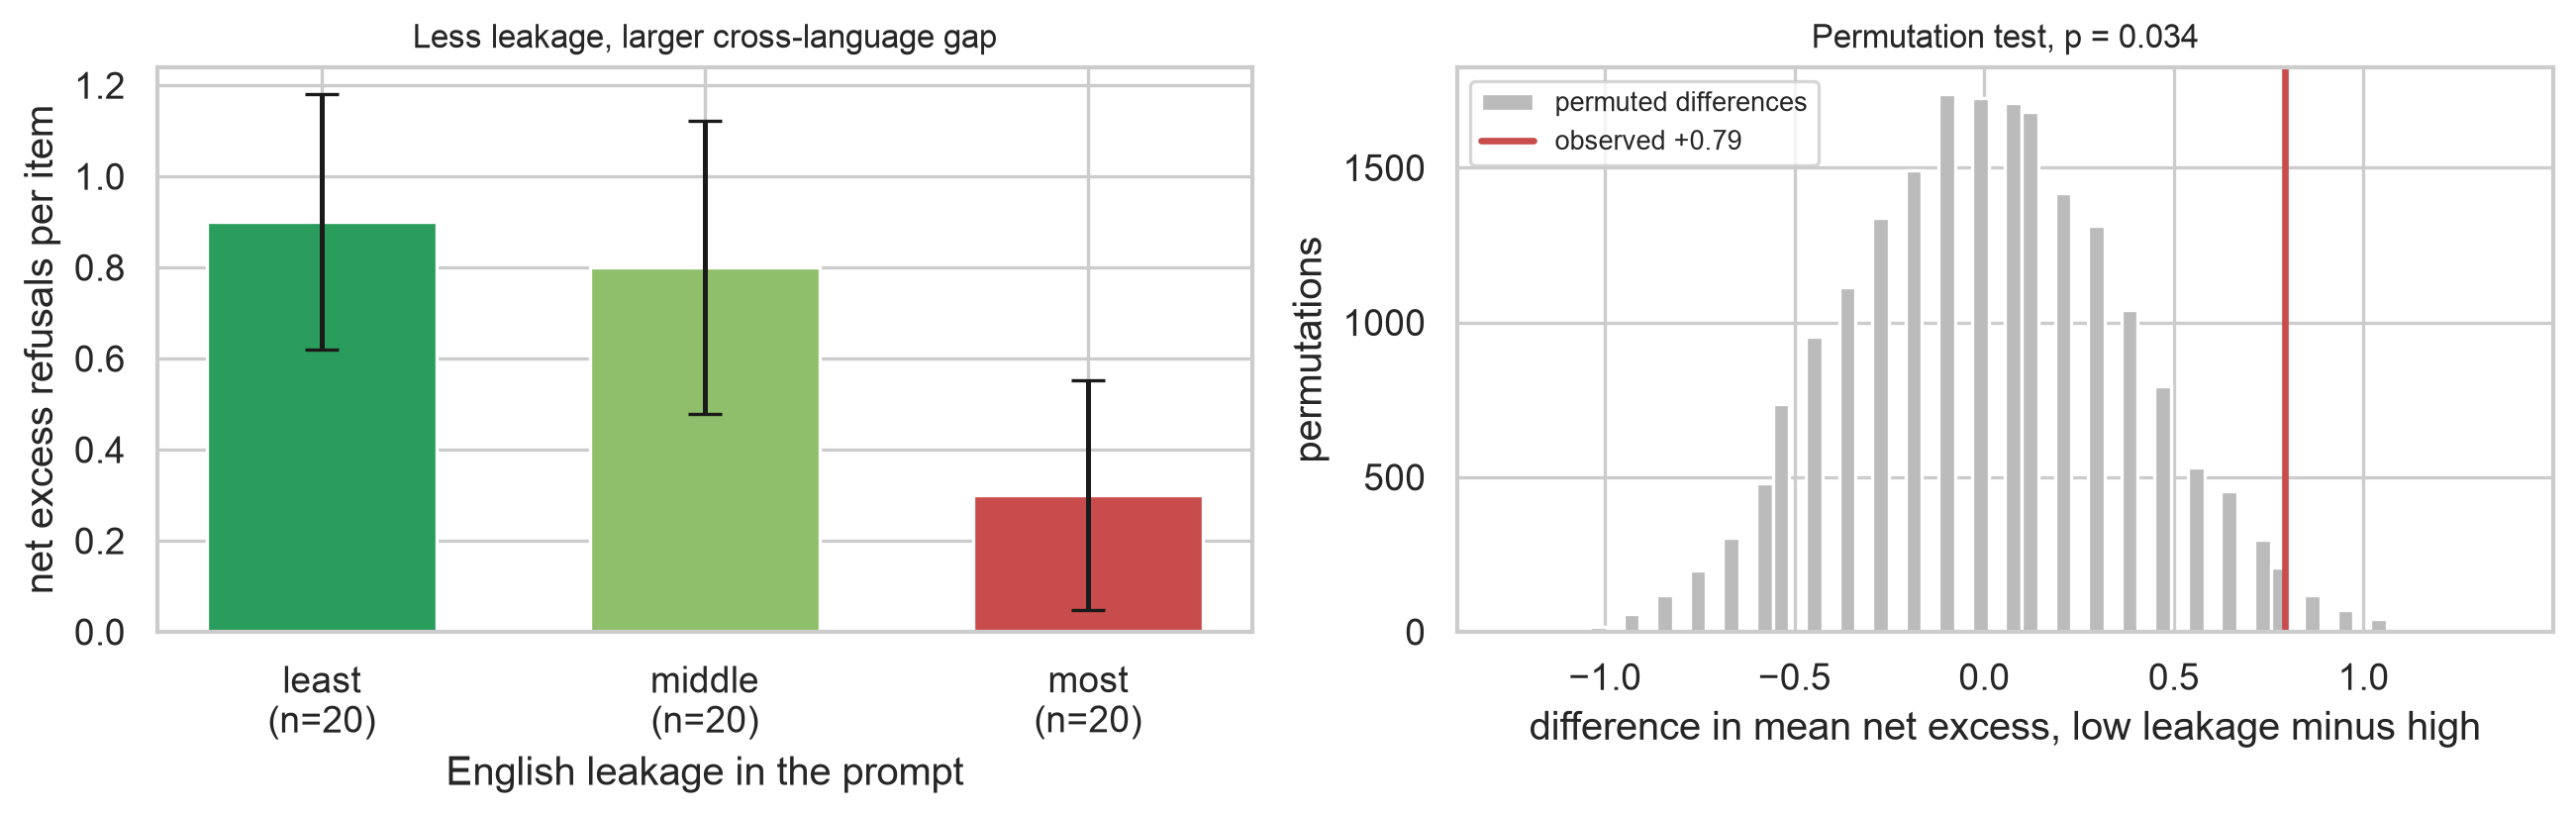

In [ ]:
_fig, _axes = plt.subplots(1, 2, figsize=(11, 3.6))
_ax = _axes[0]
_tertile = pd.qcut(leak_answerable['latin'].rank(method='first'), 3, labels=['least', 'middle', 'most'])
_grouped = leak_answerable.groupby(_tertile, observed=True)['net_excess']
means = _grouped.mean()
errs = _grouped.std() / np.sqrt(_grouped.size())
_ax.bar(np.arange(3), means.values, yerr=errs.values, capsize=5, color=['#2a9d5c', '#8fbf6a', '#c94c4c'], width=0.6)
# normal approximation is fine for a mean of a bounded count at these sizes
_ax.set_xticks(np.arange(3), [f'{label}\n(n={n})' for label, n in zip(means.index, _grouped.size())])
_ax.set_xlabel('English leakage in the prompt')
_ax.set_ylabel('net excess refusals per item')
_ax.set_title('Less leakage, larger cross-language gap', fontsize=10)
_ax = _axes[1]
_ax.hist([draws], bins=60, color='#bbb', label='permuted differences')
_ax.axvline(observed, color='#c94c4c', lw=2, label=f'observed {observed:+.2f}')
_ax.set_xlabel('difference in mean net excess, low leakage minus high')
_ax.set_ylabel('permutations')
_ax.set_title(f'Permutation test, p = {perm_p:.3f}', fontsize=10)
_ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**The direction is consistent. The size is not pinned down.** Both halves of that matter, and David's split (+0.79, p = 0.034) reports only the first half.

Cleaner items show a **larger** English-versus-other refusal gap, not a smaller one. That holds under four of the five splits, across both tertile breakdowns, and in both rank correlations, which are negative at -0.19 and -0.25. Nothing in this data supports the idea that leakage manufactured the cross-language effect. If anything it was pulling the measured effect towards zero, which is what one would expect if the model is responding to the language of its input, since a prompt still carrying English is closer to the English condition.

The size is another matter. The five splits give differences from -0.08 to +0.79 and p values from 0.03 to 0.90, on the same 60 items:

- David's split gives the largest difference (+0.79) and the only p below 0.05 (0.034).
- Our own transparent rule at the same threshold, `latin_max <= 8`, selects 17 items too but only 13 of the same ones. Swapping those four items takes the difference down to +0.30 and the p to 0.44.
- A median split gives +0.60 at p = 0.086 on the Latin measure and +0.54 at p = 0.129 on the prose measure.
- The strictest rule, `latin_max <= 5`, has the sign the other way at -0.08, on 10 items.

So the headline p = 0.034 is the most favourable of several defensible choices, and it comes from David's split rather than from our leakage measures. **Report the direction, not the magnitude,** and treat the claim as "leakage is not creating the effect and looks like it dilutes it" rather than as a measured dilution of a particular size.

**One further caveat.** This is an observational split rather than a randomised one, and section 1 showed leakage correlates with the length of the English source item at rho 0.43. Longer items could be harder for reasons unrelated to language. The paired design already removes anything that makes an item uniformly hard, so the confound would have to act specifically on the English-versus-other contrast, but it cannot be excluded from these data alone.

## 5. Answer accuracy, for completeness

The same restriction applied to the other answerable-side metric.

In [ ]:
_rows = []
for _run in RUNS:
    _keep = [i for i in correct_wide.index if i in subset_ids[_run]]
    _sub = correct_wide.loc[_keep]
    row = {'subset': f'dir {_run}', 'n': len(_sub)}
    row.update({_lang: _sub[_lang].mean() for _lang in LANGS})
    row['mean gap vs en'] = np.mean([_sub['en'].mean() - _sub[_lang].mean() for _lang in OTHER])
    _rows.append(row)
print('answer accuracy by subset')
print(pd.DataFrame(_rows).set_index('subset').round(3).to_string())

answer accuracy by subset
         n     en     pl     ru  zh_cmn  zh_yue  mean gap vs en
subset                                                         
dir 0   60  0.667  0.500  0.517   0.517   0.550           0.146
dir 3    6  0.500  0.000  0.333   0.333   0.167           0.292
dir 5    8  0.625  0.250  0.500   0.250   0.250           0.312
dir 8   17  0.471  0.294  0.412   0.235   0.294           0.162


The gap against English widens in every subset, sharply in dirs 3 and 5 and only marginally in dir 8. That is the same direction as section 3.

The absolute levels fall for every language including English, which is the composition effect from section 2 rather than anything to do with language. Read down a column and it looks as though the model got worse on the cleaner items. It did not. The cleaner items are a different and harder mix, English included, which is exactly why these columns must not be compared across rows.

## 6. Conclusions

### The answer to the question asked

1. **Filtering to the cleaner subsets does not weaken the cross-language finding.** The English-versus-other false refusal gap stays positive in all twelve language-by-subset cells and grows in ten of them, the exceptions being Russian in dirs 5 and 8 where it narrows by a single item. The disagreements also become entirely one-sided: across all twelve language-by-subset cells in dirs 3, 5 and 8 there is not a single item where English refuses and the translated version does not, against six such items on the full run. Nothing in this notebook gives a reason to revise the main notebook's conclusions.

2. **English leakage looks like it dilutes the effect rather than creating it.** Cleaner items show a larger gap under four of five splits, monotonically across tertiles on both leakage measures, with both rank correlations negative. The direction is consistent. **The size is not.** David's split gives +0.79 at p = 0.034. The same threshold applied through our own leakage measure gives +0.30 at p = 0.44. Report the direction and treat the main notebook's estimate as probably conservative rather than measurably so.

3. **The subsets cannot answer the question on their own.** With 6, 8 and 17 answerable items they are underpowered by construction, and dir 3 cannot reach p = 0.05 at any effect size. They are also badly unbalanced against the design, losing an entire perturbation class, so any full-versus-filtered comparison of a raw metric would be measuring composition rather than leakage.

4. **Low leakage is not the same as well translated.** The measure that the subsets track correlates with the length of the English source item at rho 0.43, because names and titles stay in Latin script. It also cannot see Polish at all, since Polish is Latin-script throughout, and Polish shows one of the largest gaps. Whatever these subsets select, it is only partly translation quality.

### What to do instead (by Claude)

5. **Do not use these three directories as an evaluation filter.** If a leakage control is wanted, score leakage over all 180 items and use it as a covariate, as in section 4. That keeps the design balanced and keeps n at 60 rather than 6. Report the result under more than one split, because section 4 shows a four-item change of definition can move p by an order of magnitude at this sample size.

6. **Human review of the translations is still outstanding.** The prose measure says most items carry no untranslated English function words at all, which is weak evidence of quality rather than a substitute for a speaker of each language reading them.

7. **Record the provenance of any future filter.** A one-line note next to the directories saying what was thresholded and why would remove the guesswork entirely.

### Follow-up, now done

8. **The judge's prompt language does not explain the cross-language result either.** Every result here rests on an English-instructed judge reading translated responses, and a judge that is systematically stricter on non-English text would produce this same pattern. The target-language judge run now exists in `data/pilot_v2_eval_localised` and is analysed in [`pilot_v2_judge_prompt_language.ipynb`](pilot_v2_judge_prompt_language.ipynb). It clears the judge. Consensus classification labels are identical on 896 of 900 items, no consensus metric moves by more than 0.017, and the paired false refusal result holds in all four languages under both instruments. The English slice acts as a placebo there, because the English localised prompt is the canonical prompt, so the non-English changes can be read against a measured nondeterminism floor.